
# Advanced RAG System with LangGraph (Research Paper Assistant)

**Objective:** Build an advanced Retrieval-Augmented Generation (RAG) system using **LangGraph** to answer questions from deep learning research papers.

**Key Features:**
1.  **Multi-Node Graph:** Retrieve -> Generate -> Judge -> (Improve/End).
2.  **Dynamic Retrieval:** Switch between Semantic, BM25, and Hybrid retrieval strategies at runtime.
3.  **Self-Correction:** An LLM Judge evaluates answers and triggers improvements if needed.
4.  **Configurable Backend:** Easy switching between OpenAI, Gemini, and Anthropic.

**Documents:**
- Attention Is All You Need (Transformer)
- Deep Residual Learning for Image Recognition (ResNet)
- Language Models are Few-Shot Learners (GPT-3)


In [1]:

# !pip install langgraph==0.6.5 langchain==0.3.27 langchain-openai==0.3.29 langchain-community==0.3.27 langchain-chroma==0.2.5 rank-bm25==0.2.2 arxiv==2.1.3 pymupdf==1.24.10 langchain-google-genai==2.0.0 langchain-anthropic==0.2.0 --quiet
!pip install -qU langchain==1.2.7 langchain-openai==1.1.7 langchain-google-genai==4.2.0 langchain-community==0.4.1 chromadb==1.4.1 tiktoken arxiv==2.1.3 pymupdf==1.24.10 langgraph==1.0.7 langgraph-sdk>=0.1.57 langchain-text-splitters==1.1.0 langchain-chroma==1.1.0 rank_bm25==0.2.2


ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.
google-adk 1.23.0 requires opentelemetry-api<=1.37.0,>=1.37.0, but you have opentelemetry-api 1.39.1 which is incompatible.
google-adk 1.23.0 requires opentelemetry-sdk<=1.37.0,>=1.37.0, but you have opentelemetry-sdk 1.39.1 which is incompatible.
opentelemetry-exporter-gcp-logging 1.11.0a0 requires opentelemetry-sdk<1.39.0,>=1.35.0, but you have opentelemetry-sdk 1.39.1 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-exporter-otlp-proto-common==1.37.0, but you have opentelemetry-exporter-otlp-proto-common 1.39.1 which is incompatible.
opentelemetry-exporter-otlp-proto-http 1.37.0 requires opentelemetry-proto==1.37.0, but you have opentelemetry-proto 1.39.1 which is incompat

In [20]:
!pip install rank_bm25

In [2]:

import os
import getpass
from langchain_openai import ChatOpenAI, OpenAIEmbeddings
# Uncomment these if you have keys and want to use them
# from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
# from langchain_anthropic import ChatAnthropic

# Configuration
LLM_PROVIDER = "openai"  # Options: "openai", "google", "anthropic"

# OpenAI API Key
if not os.environ.get("OPENAI_API_KEY"):
    os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API key: ")

# Placeholders for other keys
# if LLM_PROVIDER == "google" and not os.environ.get("GOOGLE_API_KEY"):
#     os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google API key: ")
# if LLM_PROVIDER == "anthropic" and not os.environ.get("ANTHROPIC_API_KEY"):
#     os.environ["ANTHROPIC_API_KEY"] = getpass.getpass("Enter your Anthropic API key: ")

def get_llm_model(provider=LLM_PROVIDER, temperature=0):
    if provider == "openai":
        return ChatOpenAI(model="gpt-4o-mini", temperature=temperature)
    elif provider == "google":
        # return ChatGoogleGenerativeAI(model="gemini-pro", temperature=temperature)
        raise NotImplementedError("Uncomment google imports to use Gemini")
    elif provider == "anthropic":
        # return ChatAnthropic(model="claude-3-opus-20240229", temperature=temperature)
        raise NotImplementedError("Uncomment anthropic imports to use Claude")
    else:
        raise ValueError(f"Unknown provider: {provider}")

def get_embedding_model(provider=LLM_PROVIDER):
    if provider == "openai":
        return OpenAIEmbeddings(model="text-embedding-3-small")
    elif provider == "google":
        # return GoogleGenerativeAIEmbeddings(model="models/embedding-001")
        raise NotImplementedError("Uncomment google imports to use Gemini embeddings")
    else:
        return OpenAIEmbeddings(model="text-embedding-3-small")


Enter your OpenAI API key: ··········



## Data Loading: Research Papers

We will load three seminal deep learning papers from ArXiv:
1. **Attention Is All You Need** (1706.03762)
2. **Deep Residual Learning for Image Recognition** (1512.03385)
3. **Language Models are Few-Shot Learners** (2005.14165)


In [3]:

from langchain_community.document_loaders import ArxivLoader

def load_arxiv_papers(paper_ids):
    docs = []
    for pid in paper_ids:
        print(f"Loading paper {pid}...")
        loader = ArxivLoader(query=pid, load_max_docs=1)
        # ArxivLoader creates one big doc per paper usually, or pages.
        # We'll just load them.
        loaded_docs = loader.load()
        for d in loaded_docs:
             d.metadata["source_paper_id"] = pid
        docs.extend(loaded_docs)
    return docs

paper_ids = ["1706.03762", "1512.03385", "2005.14165"]
raw_docs = load_arxiv_papers(paper_ids)
print(f"Loaded {len(raw_docs)} papers.")


Loading paper 1706.03762...
Loading paper 1512.03385...
Loading paper 2005.14165...
Loaded 3 papers.


In [4]:

from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size=500,
    chunk_overlap=50
)
chunks = text_splitter.split_documents(raw_docs)
print(f"Generated {len(chunks)} chunks.")


Generated 745 chunks.


In [5]:

from langchain_chroma import Chroma

# Initialize Embedding Model
embeddings = get_embedding_model()

# Create Vector Store
# Note: In a real run, we might want to clean up the directory first if it exists
# !rm -rf research_papers_db
vectorstore = Chroma.from_documents(
    documents=chunks,
    embedding=embeddings,
    collection_name="research_papers_db",
    persist_directory="./research_papers_db"
)
print("Vector Store created.")


Vector Store created.


In [18]:
from langchain_classic.retrievers import EnsembleRetriever

In [21]:

from langchain_community.retrievers import BM25Retriever
from langchain_classic.retrievers import EnsembleRetriever

# 1. Semantic Retriever
semantic_retriever = vectorstore.as_retriever(search_kwargs={"k": 5})

# 2. BM25 Retriever
bm25_retriever = BM25Retriever.from_documents(chunks)
bm25_retriever.k = 5

# 3. Hybrid Retriever (Ensemble)
hybrid_retriever = EnsembleRetriever(
    retrievers=[bm25_retriever, semantic_retriever],
    weights=[0.5, 0.5]
)

print("Retrievers initialized: Semantic, BM25, Hybrid")


Retrievers initialized: Semantic, BM25, Hybrid


In [23]:

from typing import List, TypedDict, Annotated, Literal
from langgraph.graph import StateGraph, START, END
from langchain_classic.docstore.document import Document as LCDocument

class RAGState(TypedDict):
    question: str
    retrieved_docs: List[LCDocument]
    answer: str
    retrieval_strategy: str  # "semantic", "bm25", "hybrid"
    judge_score: str         # "yes", "no", "needs_improvement"
    judge_reasoning: str
    revision_count: int      # To prevent infinite loops


In [24]:

from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import JsonOutputParser

llm = get_llm_model()

# --- Generation Prompt ---
GEN_PROMPT = ChatPromptTemplate.from_template(
    """You are a helpful AI assistant specialized in research papers.
    Use the provided context to answer the question.
    If you don't know the answer or there is no relevant context, just say 'I don't know'.

    Context:
    {context}

    Question: {question}

    Answer:"""
)

# --- Judge Prompt ---
JUDGE_PROMPT = ChatPromptTemplate.from_template(
    """You are a detailed grader assessing the quality of an answer generated by an AI assistant based on the provided context.

    Context:
    {context}

    Question: {question}

    Generated Answer: {answer}

    Evaluate the answer based on these criteria:
    1. Grounding: Is the answer supported by the context?
    2. Relevance: Does it answer the question?
    3. Quality: Is it clear and detailed?

    If the answer effectively says 'I don't know', determine if the context actually contains the answer.
    - If context has the answer but model said 'I don't know', score 'needs_improvement' (tell it where to look).
    - If context does NOT have the answer and model said 'I don't know', score 'yes' (correct behavior).

    Return a JSON with:
    - "score": one of ["yes", "no", "needs_improvement"]
    - "reasoning": explanation of your score

    "yes": The answer is correct and grounded.
    "no": The answer is incorrect, hallucinated, or not based on context.
    "needs_improvement": The answer is partially correct but needs more detail, better formatting, or missed something from the context.
    """
)

# --- Improve Prompt ---
IMPROVE_PROMPT = ChatPromptTemplate.from_template(
    """You are an editor improving an answer.

    Original Question: {question}
    Original Answer: {answer}
    Context: {context}
    Judge's Feedback: {reasoning}

    Please rewrite the answer to address the feedback. Ensure it is grounded in the context.
    """
)


In [25]:

import json
from langchain_core.messages import HumanMessage

def _format_docs(docs):
    return "\n\n".join(d.page_content for d in docs)

def retrieve_node(state: RAGState) -> RAGState:
    question = state["question"]
    strategy = state.get("retrieval_strategy", "hybrid")

    print(f"Retrieving using strategy: {strategy}")

    if strategy == "semantic":
        docs = semantic_retriever.invoke(question)
    elif strategy == "bm25":
        docs = bm25_retriever.invoke(question)
    else:
        docs = hybrid_retriever.invoke(question)

    return {"retrieved_docs": docs}

def generate_node(state: RAGState) -> RAGState:
    question = state["question"]
    docs = state["retrieved_docs"]
    context = _format_docs(docs)

    chain = GEN_PROMPT | llm
    response = chain.invoke({"question": question, "context": context})

    # Reset revision count for new generation or init it
    return {"answer": response.content, "revision_count": 0}

def judge_node(state: RAGState) -> RAGState:
    question = state["question"]
    answer = state["answer"]
    docs = state["retrieved_docs"]
    context = _format_docs(docs)

    chain = JUDGE_PROMPT | llm | JsonOutputParser()
    try:
        score_data = chain.invoke({
            "question": question,
            "answer": answer,
            "context": context
        })
        score = score_data.get("score", "yes")
        reasoning = score_data.get("reasoning", "")
    except Exception as e:
        print(f"Judge error: {e}")
        score = "yes"
        reasoning = "Error in judging"

    print(f"Judge Score: {score}")
    print(f"Reasoning: {reasoning}")

    return {"judge_score": score, "judge_reasoning": reasoning}

def improve_node(state: RAGState) -> RAGState:
    question = state["question"]
    answer = state["answer"]
    docs = state["retrieved_docs"]
    context = _format_docs(docs)
    reasoning = state["judge_reasoning"]

    print("Improving answer...")

    chain = IMPROVE_PROMPT | llm
    response = chain.invoke({
        "question": question,
        "answer": answer,
        "context": context,
        "reasoning": reasoning
    })

    return {
        "answer": response.content,
        "revision_count": state.get("revision_count", 0) + 1
    }

def give_up_node(state: RAGState) -> RAGState:
    print("Giving up (irrelevant context).")
    return {"answer": "I don't know if there is relevant context."}


In [26]:

def check_judge_score(state: RAGState) -> str:
    score = state["judge_score"]
    count = state.get("revision_count", 0)

    if score == "no":
        return "give_up"
    elif score == "needs_improvement":
        if count < 3:
            return "improve"
        else:
            print("Max revisions reached. Stopping.")
            return END
    else:
        return END

builder = StateGraph(RAGState)

builder.add_node("retrieve", retrieve_node)
builder.add_node("generate", generate_node)
builder.add_node("judge", judge_node)
builder.add_node("improve", improve_node)
builder.add_node("give_up", give_up_node)

builder.add_edge(START, "retrieve")
builder.add_edge("retrieve", "generate")
builder.add_edge("generate", "judge")

builder.add_conditional_edges(
    "judge",
    check_judge_score,
    {
        "give_up": "give_up",
        "improve": "improve",
        END: END
    }
)

builder.add_edge("improve", "judge")
builder.add_edge("give_up", END)

graph = builder.compile()
print("Graph compiled.")


Graph compiled.


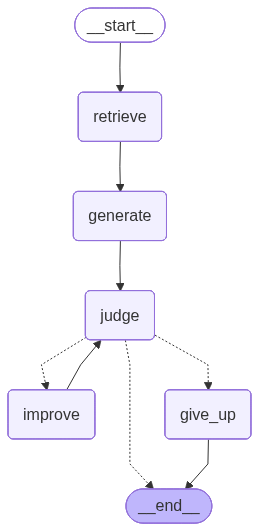

In [27]:

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Graph visualization failed: {e}")



## Evaluation: Comparison of Retrieval Strategies

We will compare the answers generated using different retrieval strategies (`semantic`, `bm25`, `hybrid`) for two specific questions.


In [28]:

eval_questions = [
    "How does the multi-head attention mechanism work?",
    "What is the vanishing gradient problem and how does ResNet solve it?"
]

strategies = ["semantic", "bm25", "hybrid"]

print(f"{'Question':<50} | {'Strategy':<10} | {'Answer Preview'}")
print("-" * 100)

for q in eval_questions:
    for strategy in strategies:
        # Run graph with specific strategy
        inputs = {"question": q, "retrieval_strategy": strategy}
        result = graph.invoke(inputs)
        answer = result["answer"].replace("\n", " ")[:100] + "..."
        print(f"{q[:47]:<50} | {strategy:<10} | {answer}")
    print("-" * 100)


Question                                           | Strategy   | Answer Preview
----------------------------------------------------------------------------------------------------
Retrieving using strategy: semantic
Judge Score: yes
Reasoning: The answer effectively explains how the multi-head attention mechanism works, aligning well with the context provided. It accurately describes the process of using queries, keys, and values, the computation of attention heads, the concatenation of outputs, and the weighted sum of values. The details are clear and relevant to the question asked.
How does the multi-head attention mechanism wor    | semantic   | The multi-head attention mechanism works by allowing the model to jointly attend to information from...
Retrieving using strategy: bm25
Judge Score: yes
Reasoning: The generated answer effectively explains how the multi-head attention mechanism works, and it is well-supported by the context provided. It accurately describes the process of 


## Examples: Judge & Improvement

Let's test the self-correction capabilities.


In [29]:

# Test with an irrelevant question
q_irrelevant = "What is the capital of France?"
result = graph.invoke({"question": q_irrelevant})
print(f"Question: {q_irrelevant}")
print(f"Final Answer: {result['answer']}")
print(f"Judge Score: {result.get('judge_score')}")


Retrieving using strategy: hybrid
Judge Score: needs_improvement
Reasoning: The answer 'I don't know' is not appropriate because the context does not provide information about the capital of France. However, the model should have recognized that the question is asking for a specific fact that is not present in the context. Therefore, it should have indicated that the answer is not available based on the provided context.
Improving answer...
Judge Score: yes
Reasoning: The answer correctly identifies Paris as the capital of France. However, it also notes that the context does not contain information about the capital of France, which is accurate since the provided context does not mention Paris or France at all. Therefore, the model's response of 'I cannot provide further details based on that context' is appropriate, as the context does not support the question.
Question: What is the capital of France?
Final Answer: **Revised Answer:** The capital of France is Paris. However, the provi

In [ ]:

# Test with a complex question
q_complex = "Explain the difference between soft and hard attention."
# Note: The context might not have explicit 'soft vs hard' distinction in 'Attention Is All You Need'
# (which focuses on self-attention), so this is a good test for the Judge.
result = graph.invoke({"question": q_complex})
print(f"Question: {q_complex}")
print(f"Final Answer: {result['answer']}")
print(f"Revisions: {result.get('revision_count', 0)}")


Retrieving using strategy: hybrid
Judge Score: needs_improvement
Reasoning: The answer 'I don't know' indicates a lack of information, but the context does contain relevant information about attention mechanisms, including self-attention, which could be related to the concepts of soft and hard attention. The model should have referenced the context discussing attention mechanisms to provide a more informative response.
Improving answer...
Judge Score: needs_improvement
Reasoning: The answer provides a good explanation of the differences between soft and hard attention, but it lacks direct grounding in the provided context. While it mentions self-attention and the 'Scaled Dot-Product Attention' mechanism, it does not explicitly connect these concepts to the definitions of soft and hard attention. Additionally, the context discusses attention mechanisms in detail, which could have been referenced more explicitly to strengthen the grounding. The answer could be improved by incorporating s